In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'

import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp

from priors import convert_bilby_prior
from variational import fit

from inference import get_model
from inference import get_selection
from inference import get_event_data

/home/noah.wolfe/.conda/envs/just-for-kicks/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from gravpop import MarginalizedHybridLikelihood

event_data = get_event_data()
selection_func = get_selection()

HL = MarginalizedHybridLikelihood(
    event_data=event_data,
    selection_data=selection_func,
    models=get_model(),
    models_selection=get_model(),
    fix_kernels_selection={},
    fix_kernels_events={}
)

In [3]:
param_keys, bounds, log_prior, fold = convert_bilby_prior('./lvk.prior')

def unravel(x):
    return dict(zip(param_keys, x))

def pack(x):
    return fold(unravel(x))

def log_posterior(parameters):
    parameters = pack(parameters)
    return log_prior(parameters) + HL.logpdf(parameters)

In [4]:
from flows import default_flow
flow = default_flow(jax.random.key(1), bounds, nn_block_dim=8)

In [5]:
flow, loss = fit(
    jax.random.key(1),
    flow,
    lambda x: log_prior(pack(x)),
    clip=False,
    lr=1,
    batch_size=10_000,
    steps=1_000
)

train: 100%|██████████| 1000/1000 [00:04<00:00, 225.39it/s]


Array(0.41164517, dtype=float64)

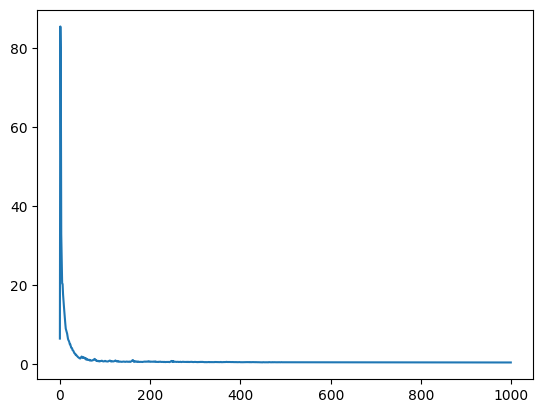

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(range(1_000), loss);
loss[-1]

In [ ]:
flow_post, loss_post = fit(
    jax.random.key(3),
    flow,
    log_posterior,
    clip=True,
    lr=1e-1,
    final_
    batch_size=1,
    steps=50_000
)

train: 100%|██████████| 50000/50000 [11:18<00:00, 73.66it/s]


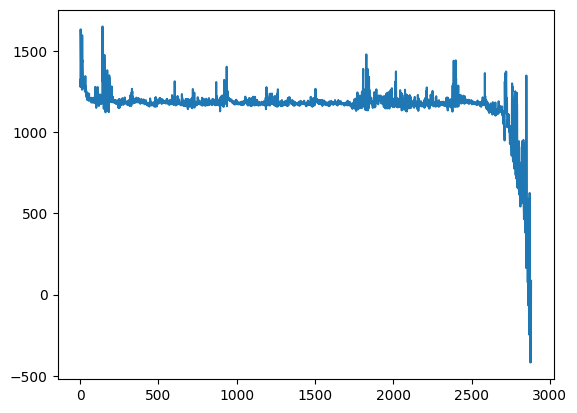

In [11]:
fig, ax = plt.subplots()
ax.plot(loss_post)

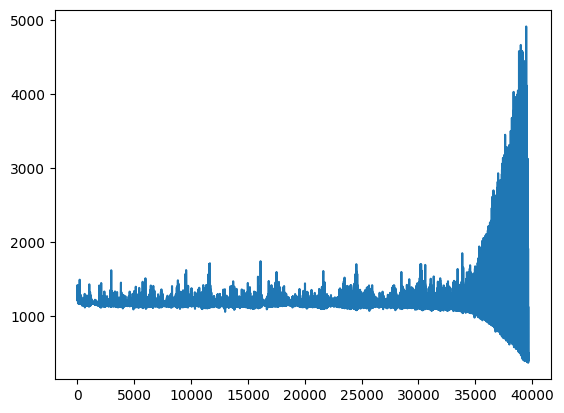

In [8]:
fig, ax = plt.subplots()
ax.plot(loss_post)

In [12]:
loss_post[-1]

Array(nan, dtype=float64)

In [33]:
jnp.sum(jnp.isfinite(loss)) / len(loss)

Array(1., dtype=float64)

In [17]:
n = 10_000
qs, log_q = flow_post.sample_and_log_prob(
    jax.random.key(4),
    (n,)
)

In [23]:
from jax_tqdm import scan_tqdm

@scan_tqdm(n)
def step(carry, d):
    _, x = d
    parameters = pack(x)
    ll = HL.logpdf(parameters)
    lpr = log_prior(parameters)
    return carry, (ll, lpr)

_, (ll, lpr) = jax.lax.scan(step, None, (jnp.arange(n), qs))

Running for 10,000 iterations: 100%|██████████| 10000/10000 [00:53<00:00, 187.90it/s]


In [24]:
log_w = ll - log_q

In [25]:
import numpy as np
from arviz import psislw
slw, kss = psislw(np.array(log_w), normalize=False)

In [26]:
kss

array(5.84668669)

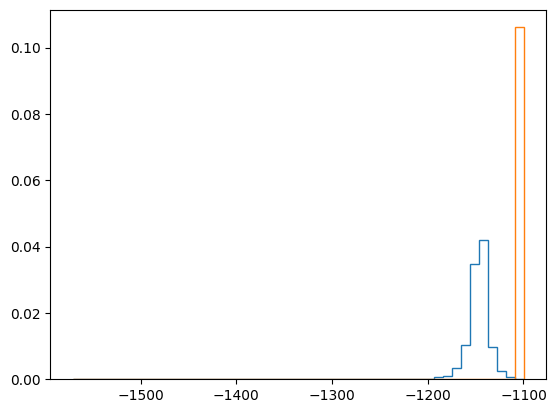

In [27]:
fig, ax = plt.subplots()
ax.hist(ll, histtype='step', bins=50, density=True)

weights = np.exp(slw - slw.max())
ax.hist(ll, histtype='step', bins=50, density=True, weights=weights);

In [28]:
log_evidence = jax.scipy.special.logsumexp(log_w) - jnp.log(n)
log_norm_weights = log_w - log_evidence - jnp.log(n)
neff = jnp.exp(-jax.scipy.special.logsumexp(2 * log_norm_weights))

neff / 100

Array(0.01000918, dtype=float64)

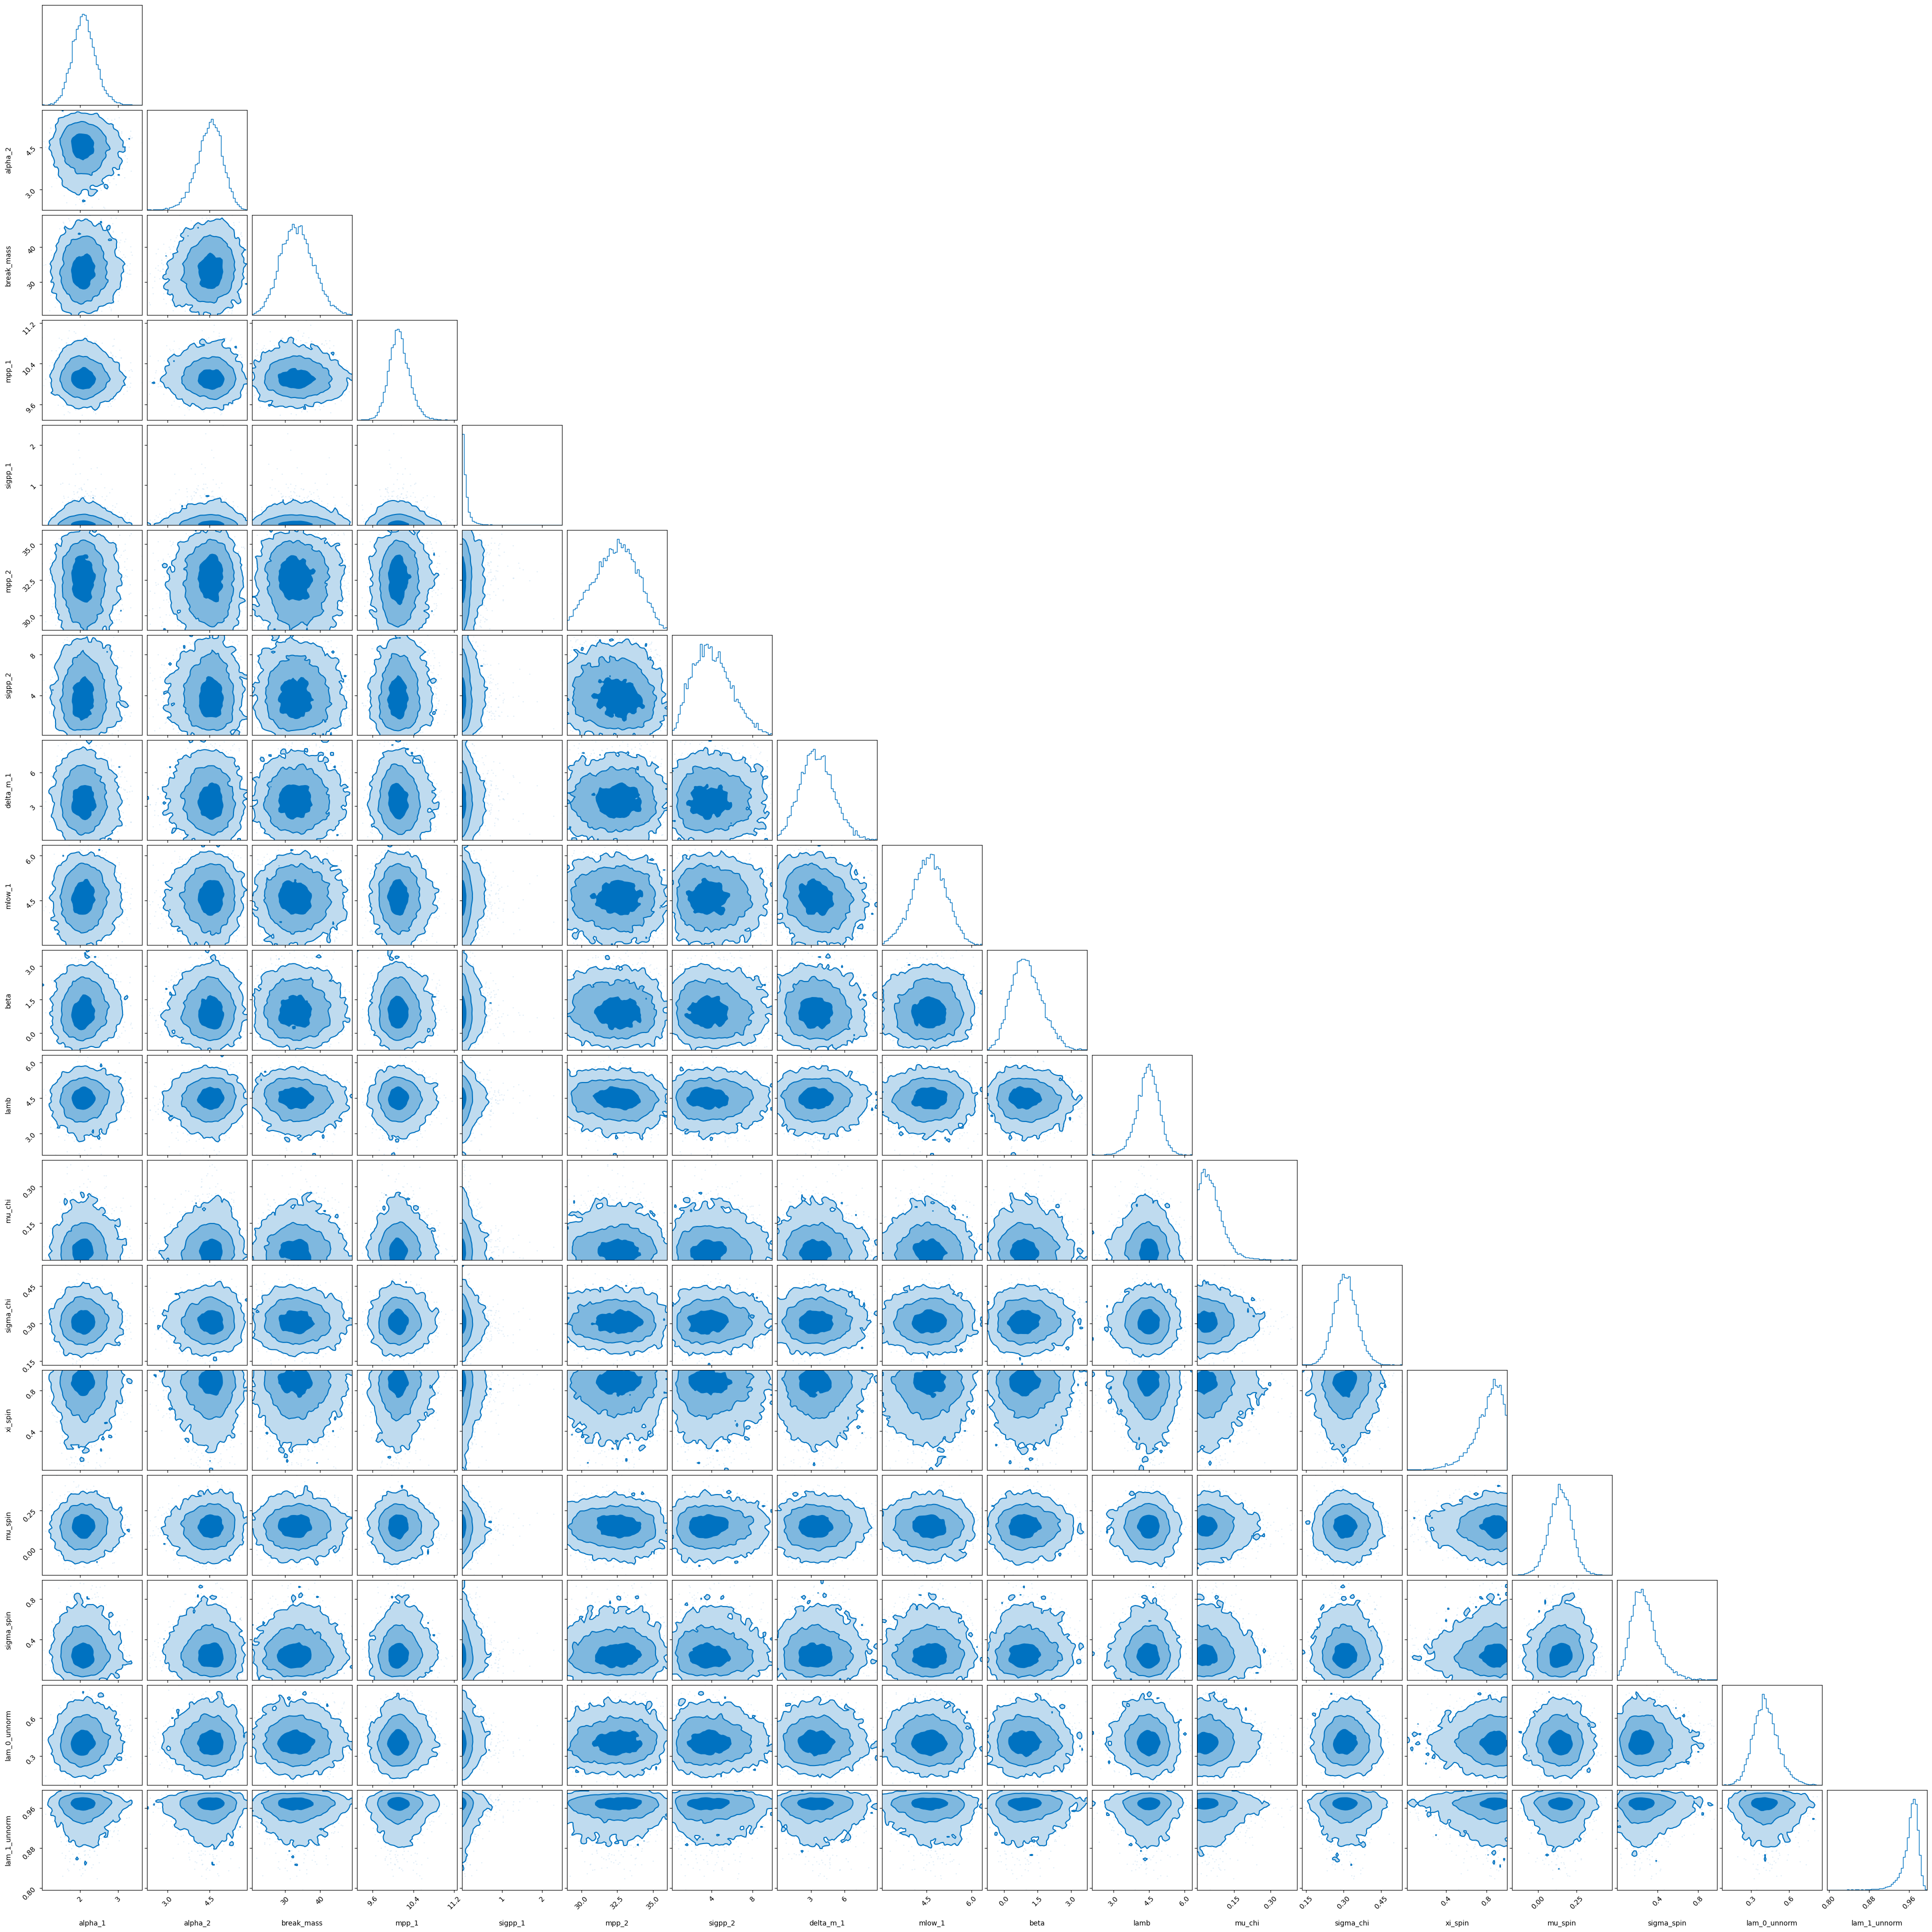

In [29]:
from util import plot_corner

fig = plot_corner(
    qs,
    labels=param_keys
)

In [82]:
from flows import save
save('./test-kinda-works.eqx', flow_post)